In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Lets investigate our LIHTC and Zillow dataset

In [3]:
lihtc = pd.read_csv('../data/raw/LIHTCPUB.csv')

/var/folders/jk/6_scppq56zb3dhlb6yfjslmr0000gn/T/ipykernel_66216/586854047.py:1: DtypeWarning: Columns (0: st2020, 1: nlm_spc) have mixed types. Specify dtype option on import or set low_memory=False.
  lihtc = pd.read_csv('lihtcpub/LIHTCPUB.csv')


In [4]:
lihtc.head()

,hud_id,project,proj_add,proj_cty,proj_st,proj_zip,state_id,latitude,longitude,place1990,...,n_unitsr,li_unitr,metro,dda,qct,nonprog,nlm_reason,nlm_spc,datanote,record_stat
0,AKA0000X034,YENLO PHASE I AND II,402-451 NORTH YENLO STREET,WASILLA,AK,99654,AK-99-99,61.583094,-149.437633,NaN,...,37.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X
1,AKA0000X035,LITTLE DIPPER (ACQ/REHAB),1910 TURNER STREET,FAIRBANKS,AK,99701,AK-99-99,64.829858,-147.723667,NaN,...,52.0,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,AKA19890010,PARK WEST APTS,2012 SANDVIK ST,FAIRBANKS,AK,99709,AK-89-00001,64.851646,-147.803418,1080.0,...,83.0,81.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,X
3,AKA19900005,TYSON'S TERRACE,103 BURKHART DR,SITKA,AK,99835,AK-90-00001,57.048874,-135.303021,3040.0,...,16.0,16.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,X
4,AKA19910005,NORTHWOOD APTS,190 PARKWOOD CIR,SOLDOTNA,AK,99669,AK-91-00001,60.489146,-151.073858,2810.0,...,23.0,22.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,X


In [5]:
lihtc.columns

Index(['hud_id', 'project', 'proj_add', 'proj_cty', 'proj_st', 'proj_zip',
       'state_id', 'latitude', 'longitude', 'place1990', 'place2000',
       'place2010', 'place2020', 'fips1990', 'fips2000', 'fips2010',
       'fips2020', 'st2020', 'cnty2020', 'scattered_site_cd',
       'resyndication_cd', 'allocamt', 'n_units', 'li_units', 'n_0br', 'n_1br',
       'n_2br', 'n_3br', 'n_4br', 'aff_period', 'aff_yrs', 'inc_ceil',
       'low_ceil', 'ceilunit', 'yr_pis', 'yr_alloc', 'non_prof', 'basis',
       'bond', 'mff_ra', 'fmha_514', 'fmha_515', 'fmha_538', 'home',
       'home_amt', 'tcap', 'tcap_amt', 'cdbg', 'cdbg_amt', 'htf', 'htf_amt',
       'fha', 'hopevi', 'hpvi_amt', 'tcep', 'tcep_amt', 'rad', 'qozf',
       'qozf_amt', 'rentassist', 'trgt_pop', 'trgt_fam', 'trgt_eld',
       'trgt_dis', 'trgt_hml', 'trgt_other', 'trgt_spc', 'type', 'credit',
       'n_unitsr', 'li_unitr', 'metro', 'dda', 'qct', 'nonprog', 'nlm_reason',
       'nlm_spc', 'datanote', 'record_stat'],
      dtype='

In [6]:
#The data dictionary explains these columns and what different values mean
#The biggest goal is first to join across counties
#We can use the census code from the latest census (2020) in fips2020

In [7]:
#Lets make a join key to connect with the zillow data

In [8]:
lihtc['join_key'] = lihtc['fips2020'].astype(str).str[:5]

In [9]:
#Before joining, we need to aggregate the lihtc data
#Zillow indices are at the county level so we need to match that

In [10]:
lihtc_county = (
    #Removes rows with a missing year
    lihtc[lihtc['yr_pis'] != 9999]
    .groupby(['join_key', 'yr_pis'])
    #Get number of lihtc units (often mixed with market rate housing) and total projects
    .agg(new_li_units=('li_units', 'sum'), n_projects=('hud_id', 'count'))
    .reset_index()
)

In [11]:
#When thinking about how lihtc unit affect prices, we need to consider that units that units are generally permanent
#Meaning we shouldn't just look at the num of new units, but rather the cumulative # of units in an area as of a given year
#Because the X number of units built in a county in year 1 are still there in year 2, and this excess supply could affect prices

In [12]:
#So we need a cumulative sum column

In [13]:
#First lets sort
lihtc_county = lihtc_county.sort_values(['join_key', 'yr_pis'])

In [14]:
#Now we get a cumulative sum across all year
lihtc_county['cum_li_units'] = lihtc_county.groupby('join_key')['new_li_units'].cumsum()

In [15]:
lihtc_county.head()

,join_key,yr_pis,new_li_units,n_projects,cum_li_units
0,01001,1993,3.0,1,3.0
1,01001,1999,44.0,1,47.0
2,01001,2000,28.0,1,75.0
3,01001,2003,80.0,1,155.0
4,01001,2009,152.0,2,307.0


In [16]:
#Great, our lihtc dataset looks great
#Lets also bring in our home price index ZHVI

In [17]:
zhvi = pd.read_csv('../data/raw/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')

In [18]:
zhvi.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,2000-01-31,...,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28
0,3101,0,Los Angeles County,county,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",6,37,209546.781542,...,871682.989562,867498.066045,865580.206289,865544.590524,867640.385191,870465.816563,873686.642817,877199.364161,878875.348952,878850.952966
1,139,1,Cook County,county,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",17,31,147112.165140,...,309469.020573,309480.053807,310206.374415,311109.046548,312454.747998,313740.261455,315228.809700,316805.091147,318219.950510,319888.062715
2,1090,2,Harris County,county,TX,TX,"Houston-The Woodlands-Sugar Land, TX",48,201,111561.888995,...,283593.291354,282547.484490,281686.340390,280931.806109,280379.381295,279925.346845,279694.608076,279740.895624,279594.876137,279263.989514
3,2402,3,Maricopa County,county,AZ,AZ,"Phoenix-Mesa-Chandler, AZ",4,13,145627.020264,...,464951.920553,463059.089143,461025.279172,459359.738274,458281.503999,457850.654029,458073.934788,458856.215028,459706.814907,460378.214783
4,2841,4,San Diego County,county,CA,CA,"San Diego-Chula Vista-Carlsbad, CA",6,73,216092.721115,...,938057.300718,932785.637153,928379.647280,924935.436445,923067.259914,923035.511553,924041.271657,926211.931053,927440.662021,928459.216322


In [19]:
#This is a wide table where the dates are columns and values are price indices

In [20]:
#Let's melt this dataset so it's a long table with date as a column
#Then we can aggregate the values and join to an 

In [21]:
zhvi = pd.melt(
    zhvi, 
    id_vars=zhvi.columns[:9], 
    value_vars=zhvi.columns[9:],
    var_name='date', 
    value_name='zhvi_value'
)

In [22]:
#Lets convert the dates to a timestamp
zhvi['date'] = pd.to_datetime(zhvi['date'])

In [23]:
#Also for the sake of modeling wit PyMC easier to remove NaN

In [24]:
zhvi = zhvi.dropna(subset=["zhvi_value"])

In [25]:
#We'll eventually join to the lihtc table which is county and year
#So make a join key (county code from FIPS)

In [26]:
zhvi['join_key'] = zhvi['StateCodeFIPS'].astype(str).str.zfill(2) + zhvi['MunicipalCodeFIPS'].astype(str).str.zfill(3)

In [27]:
#Now we take the average price for a year/county
zhvi['year'] = zhvi['date'].dt.year

In [28]:
#Lets include State so it's easier to plot in the future
zhvi_annual = zhvi.groupby(['join_key','State','year'])['zhvi_value'].mean().reset_index()

In [29]:
zhvi_annual.head()

,join_key,State,year,zhvi_value
0,01001,AL,2000,122006.919306
1,01001,AL,2001,126782.889410
2,01001,AL,2002,128604.758955
3,01001,AL,2003,132888.041386
4,01001,AL,2004,137618.587247


In [30]:
#Now let's bring in our rental data

In [31]:
zori = pd.read_csv('../data/raw/County_zori_uc_sfrcondomfr_sm_sa_month.csv')

In [32]:
zori.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,2015-01-31,...,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28
0,3101,0,Los Angeles County,county,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",6,37,1701.506938,...,2775.651884,2779.380279,2783.680584,2788.547358,2791.965641,2795.367811,2796.729405,2797.397530,2789.742094,2782.573528
1,139,1,Cook County,county,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",17,31,1436.899052,...,2125.958655,2137.230893,2148.489268,2158.924361,2169.105674,2176.803010,2184.007893,2190.430827,2200.683170,2210.232414
2,1090,2,Harris County,county,TX,TX,"Houston-The Woodlands-Sugar Land, TX",48,201,1184.359545,...,1599.774865,1595.917604,1596.452773,1596.459624,1597.646795,1595.426859,1593.569562,1590.773988,1588.313758,1584.200025
3,2402,3,Maricopa County,county,AZ,AZ,"Phoenix-Mesa-Chandler, AZ",4,13,915.984347,...,1727.844932,1728.052349,1728.182952,1728.130110,1727.960049,1728.729417,1727.623898,1726.753558,1723.170207,1719.561837
4,2841,4,San Diego County,county,CA,CA,"San Diego-Chula Vista-Carlsbad, CA",6,73,1586.414388,...,2830.736711,2832.760400,2836.263948,2844.683200,2852.034823,2857.979872,2859.520166,2863.744709,2867.441567,2871.444004


In [33]:
#Same structure as zhvi so let's repeat the same process to aggregate

In [34]:
zori = pd.melt(
    zori, 
    id_vars=zori.columns[:9], 
    value_vars=zori.columns[9:],
    var_name='date', 
    value_name='zori_value'
)

In [35]:
#Lets convert the dates to a timestamp
zori['date'] = pd.to_datetime(zori['date'])

In [36]:
#Drop NaN values like zhvi
zori = zori.dropna(subset=["zori_value"])

In [37]:
zori['join_key'] = zori['StateCodeFIPS'].astype(str).str.zfill(2) + zori['MunicipalCodeFIPS'].astype(str).str.zfill(3)

In [38]:
zori['year'] = zori['date'].dt.year

In [39]:
#Adding state like before
zori_annual = zori.groupby(['join_key', 'State', 'year'])['zori_value'].mean().reset_index()

In [40]:
zori_annual.head()

,join_key,State,year,zori_value
0,01001,AL,2021,1506.574735
1,01001,AL,2022,1560.394426
2,01001,AL,2023,1632.074462
3,01001,AL,2024,1739.233224
4,01001,AL,2025,1789.571653


In [41]:
#Great, now we're ready to join the data sets

In [42]:
#IMO I'm trying determine the effect of housing prices and rent prices separately
#So I'll create a lihtc-zhvi dataset and a lihtc-zori
#Especially since zori is limited, I dont want that to limit the amount of data I have for the zhvi dataset

In [43]:
#Lets make the joined zhvi dataset
#Keeping inner, which loses some data
#Counties in LIHTC but not in Zillow (too rural for Zillow to estimate)
#counties in Zillow but not in LIHTC (no affordable housing built) aren't useful for estimating the effect.

In [44]:
housing = lihtc_county.merge(zhvi_annual, 
                             left_on=['join_key', 'yr_pis'],
                             right_on=['join_key', 'year'])

In [45]:
housing.head()

,join_key,yr_pis,new_li_units,n_projects,cum_li_units,State,year,zhvi_value
0,01001,2000,28.0,1,75.0,AL,2000,122006.919306
1,01001,2003,80.0,1,155.0,AL,2003,132888.041386
2,01001,2009,152.0,2,307.0,AL,2009,160543.685878
3,01003,2000,40.0,1,325.0,AL,2000,133831.967205
4,01003,2001,117.0,2,442.0,AL,2001,141370.630649


In [46]:
#How many counties do we have?

In [47]:
housing['join_key'].nunique()

2076

In [48]:
#Can we see the distribution

In [49]:
#Whats the distribution of new_li_units

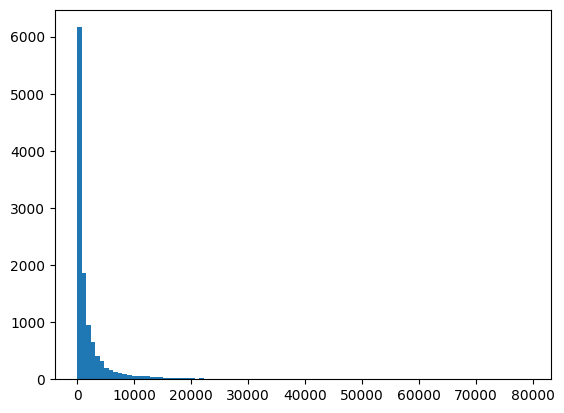

In [50]:
plt.hist(x=housing[housing['cum_li_units'] > 0]['cum_li_units'], bins=100)
plt.show()

In [51]:
#Thts a lot of 0s

In [52]:
housing['new_li_units'].value_counts(normalize=True)

new_li_units
40.0      0.032819
0.0       0.032397
48.0      0.030035
24.0      0.029950
32.0      0.021767
            ...   
1089.0    0.000084
627.0     0.000084
835.0     0.000084
873.0     0.000084
595.0     0.000084
Name: proportion, Length: 1116, dtype: float64

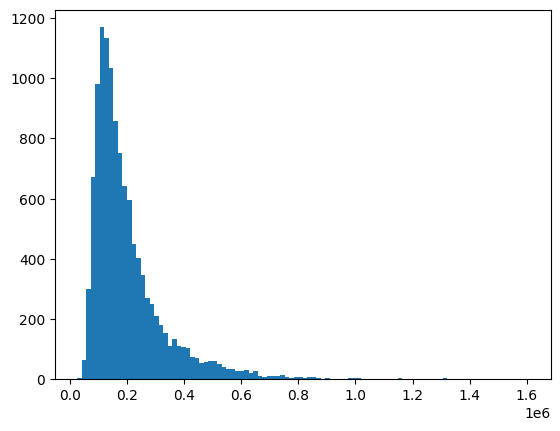

In [53]:
#Lets also plot the index value
plt.hist(x=housing['zhvi_value'], bins=100)
plt.show()

In [54]:
#Now lets join the rental dataset

In [55]:
rental = lihtc_county.merge(zori_annual, 
                             left_on=['join_key', 'yr_pis'],
                             right_on=['join_key', 'year'])

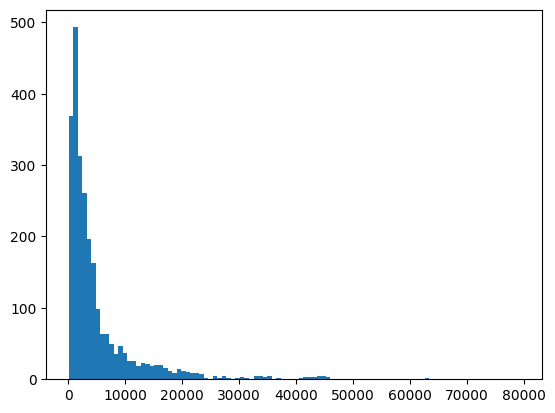

In [56]:
plt.hist(x=rental[rental['cum_li_units'] > 0]['cum_li_units'], bins=100)
plt.show()

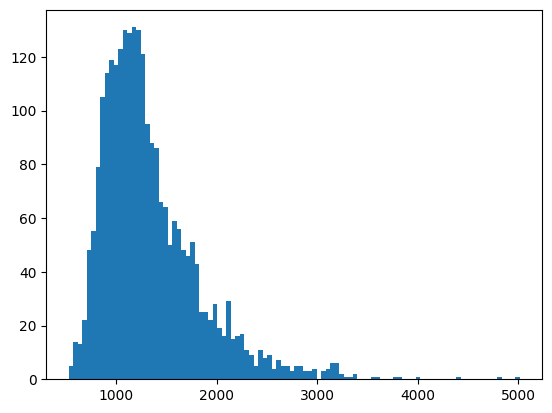

In [57]:
#Lets plot the rental index
plt.hist(x=rental['zori_value'], bins=100)
plt.show()

In [58]:
#Overall data looks okay
#Standard number of units per project
#This is actually a good sign for the Bayesian approach. 
#A frequentist regression would let those handful of massive county-years in LA and NYC dominate the estimated coefficient.
#The hierarchical model with state-level grouping naturally regularizes this — 
#the huge Texas county-years get pooled with the smaller Texas county-years through the state-level prior.

In [59]:
#Lets save both datasets to bring into separate model notebooks

In [60]:
housing.to_csv('../data/processed/housing_lihtc.csv', index=False)

In [61]:
rental.to_csv('../data/processed/rental_lihtc.csv', index=False)